<a href="https://colab.research.google.com/github/pvgbabu/AWS-Sage-Maker/blob/master/Labs/Lab_1_LLM_Prompting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hands-On Session 1: The Art of Prompting LLMs

## Overview

Welcome to Part 1(a) of our AI workshop series. In this session, you'll dive into the world of prompting large language models (LLMs), gaining some initial familiarity with effectively communicating with LLMs.

## Learning Objectives
By the end of this lab, you will:
1. Craft effective prompts for diverse AI applications
2. Understand and apply various prompting techniques
3. Gain insights into AI safety through hands-on experience

## 0. Using the tech stack

* **Google Colab**: We'll use this free, cloud-based platform for easy setup and access to computational resources. While we're focusing on Colab, you can easily replicate this project in your local computing environment. (You're here!)
* To run "cells" in Colab, either press the "Play" button in the upper left of the cell, or type Shift+Enter (hold down the keys together briefly).

* **LiteLLM**: This library helps streamline interactions with a wide range of pre-trained LLMs. We'll use it to load and run our LLMs, and interact with the LLM.

* **LLM**: We'll start with a handful of OpenAI and Gemini models.

____
## LAB 1-A: Prompting Fundamentals

For this hands-on session, we will explore:

- **Prompt Anatomy**: Explore system instructions, user inputs, and AI responses.
- **Token Mechanics**: Understand what tokens are, how they are used in LLMs, and how to estimate both input and output costs of token use.
- **Conversation Dynamics**: Compare single-turn queries and multi-turn dialogues.

To begin, we need to install litellm in order to have a simple, unified interface to communicate with an LLM

In [2]:
from google.colab import output
output.enable_custom_widget_manager()

In [3]:
#@title Installing Necessary Packages and Imports
%%capture
%pip install litellm==1.102.0 "openai>=2.20.0,<3.0.0" ipydatagrid==1.4.0

import os
import litellm
litellm.drop_params = True

from litellm import completion
from litellm import model_cost
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, Markdown, clear_output
from collections import defaultdict
from ipydatagrid import DataGrid

# The day's keys come from the workshop hub, so there is nothing to paste and
# nothing to mistype. Rerun this cell any time a key stops working.
# One key covers every model in this lab, because every call goes through OpenRouter.
import json, os, urllib.error, urllib.request

WORKSHOP_HUB = "https://tdwi-workshop-hub.vercel.app"

def load_workshop_keys(hub=WORKSHOP_HUB):
    """Ask the hub for the day's keys and load them into this session."""
    request = urllib.request.Request(
        f"{hub}/api/env", data=b"{}", headers={"content-type": "application/json"})
    try:
        with urllib.request.urlopen(request, timeout=30) as response:
            payload = json.load(response)
    except urllib.error.HTTPError as error:
        if error.code == 403:
            raise SystemExit(
                "The workshop is not running right now, so the hub is not handing out "
                "keys. If the class is in session, raise your hand and find Nicolas or "
                "Kierra.") from None
        raise SystemExit(
            f"The hub could not hand out a key (error {error.code}). Run this cell again, "
            "and raise your hand if it keeps failing.") from None
    except urllib.error.URLError:
        raise SystemExit(
            "Could not reach the workshop hub. Check that you are on the conference wifi, "
            "then run this cell again.") from None
    os.environ.update(payload)
    return sorted(payload)

print("Loaded from the hub:", ", ".join(load_workshop_keys()))



In [5]:
#@title Extract relevant available models given a few constraints

def filter_models_by_cost_and_provider(acceptable_providers: list, mode: str, max_input_cost_per_token_million: float, max_output_cost_per_token_million: float, structured_responses: bool) -> dict:
    """
    Filters models from the global model_cost dictionary based on acceptable providers and max token costs.

    Args:
        acceptable_providers: model families to keep, as they appear in an OpenRouter id
            (the 'openai' in 'openrouter/openai/gpt-4.1-nano').
        mode: The mode of the model. (chat, embedding, etc. Based on LiteLLM)
        max_input_cost_per_token_million: The maximum acceptable input cost per token (in dollars per million tokens).
        max_output_cost_per_token_million: The maximum acceptable output cost per token (in dollars per million tokens).
        structured_responses: A boolean indicating whether we want the model to support structured responses

    Returns:
        A dictionary where keys are provider names and values are lists of model information
        dictionaries that meet the specified criteria, including their blended token cost.
    """
    filtered_models = defaultdict(list)
    for model_name, model_info in model_cost.items():
        # Every call in this lab goes through OpenRouter, so the ids we care about all
        # look like openrouter/<family>/<model>. litellm reports them under one provider,
        # so the family has to come out of the id itself.
        if model_info.get('litellm_provider') != 'openrouter':
            continue
        parts = model_name.split('/')
        if len(parts) < 3:
            continue
        provider = parts[1]

        input_cost_per_token = model_info.get('input_cost_per_token') or 0
        output_cost_per_token = model_info.get('output_cost_per_token') or 0
        model_mode = model_info.get('mode')
        supports_response_schema = model_info.get('supports_response_schema', False)

        if structured_responses and not supports_response_schema:
            continue

        # Convert cost per token to cost per million tokens for comparison
        input_cost_per_token_million = round(input_cost_per_token * 1_000_000, 4)
        output_cost_per_token_million = round(output_cost_per_token * 1_000_000, 4)

        # Calculate blended cost (simple average for now)
        blended_cost_per_token_million = round((input_cost_per_token_million + output_cost_per_token_million) / 2, 4)
        if blended_cost_per_token_million == 0 or model_mode != mode:
            continue
        if provider in acceptable_providers and \
            input_cost_per_token_million <= max_input_cost_per_token_million and \
            output_cost_per_token_million <= max_output_cost_per_token_million:

            # Drop variants that are not a plain chat model: batch endpoints, image and
            # audio output, search-wired models, and the older families.
            short_name = parts[-1]
            if ':' in short_name:
                continue
            if any(tag in short_name for tag in
                   ('image', 'audio', 'tts', 'realtime', 'search', 'preview', 'instruct')):
                continue

            model_info_with_cost = model_info.copy()
            model_info_with_cost['blended_cost_per_token_million'] = blended_cost_per_token_million
            filtered_models[provider].append({model_name: model_info_with_cost})

    return filtered_models

available_models = filter_models_by_cost_and_provider(acceptable_providers=['openai', 'google'],
                                                      mode='chat',
                                                      max_input_cost_per_token_million=3,
                                                      max_output_cost_per_token_million=3,
                                                      structured_responses=True)

# The table above is the survey: everything OpenRouter will serve us under the cost cap.
# The dropdown below is a shorter list, every entry of which was tested against a live call.
# A model appearing in a catalogue is not the same as a model answering.
VERIFIED_MODELS = [
    'openrouter/openai/gpt-4.1-nano',
    'openrouter/openai/gpt-4.1-mini',
    'openrouter/openai/gpt-5-nano',
    'openrouter/openai/gpt-5-mini',
    'openrouter/google/gemini-2.5-flash',
    'openrouter/google/gemini-2.5-flash-lite',
]


### Create a simple LLM

---
Now let's try making a very simple LLM, technically a text-completion model.

In [6]:
# Options come from the verified list, not from the filtered catalogue. Every one of
# these was called successfully; offering an option that errors teaches nothing.
all_models_list = VERIFIED_MODELS


# Create the dropdown widget
model_dropdown = widgets.Dropdown(
    options=['Select a model'] + all_models_list,
    value='Select a model',
    description='Model:',
    disabled=False,
)

# Create a text input widget for the prompt
input_text = widgets.Textarea(
    value='What is the elevation of Mount Kilimanjaro?',
    placeholder='Enter your prompt here',
    description='Prompt:',
    layout=widgets.Layout(width='50%', height='100px') ,
    disabled=False
)

# Create a button
submit_button = widgets.Button(description="Submit")


# Output widget to display the table and responses
output_area = widgets.Output()

# Display the output area for the table and responses
display(output_area)

# Function to display model comparison table
def display_model_comparison_table(models_dict):
    data = []
    # Collect data and sort it
    for provider, models_info in models_dict.items():
        for model_data in models_info:
            for model_name, info in model_data.items():
                data.append({
                    'Provider': provider,
                    # The `openrouter/` prefix is the same on every row and it is what
                    # pushed the readable part of the id out of the column.
                    'Model Name': model_name.removeprefix('openrouter/'),
                    'Input Cost (per million tokens)': round(info.get('input_cost_per_token', 0) * 1_000_000, 4),
                    'Output Cost (per million tokens)': round(info.get('output_cost_per_token', 0) * 1_000_000, 4),
                    'Blended Cost (per million tokens)': info.get('blended_cost_per_token_million', 0),
                    'Supports Response Schema': info.get('supports_response_schema', False),
                    'Supports Vision': info.get('supports_vision', False),
                    'Supports Function Calling': info.get('supports_function_calling', False),
                    'RPM (Requests Per Minute)': info.get('rpm', 'N/A'),  # Add RPM
                    'TPM (Tokens Per Minute)': info.get('tpm', 'N/A')    # Add TPM
                })

    if data:
        df = pd.DataFrame(data)
        df_sorted = df.sort_values(by=['Provider', 'Model Name']).reset_index(drop=True)
        with output_area:
            clear_output(wait=True)
            grid = DataGrid(df_sorted)
            grid.auto_fit_columns=True
            # Set last, so it wins over the auto fit. Model Name is the one column
            # nobody can reconstruct from a truncation.
            grid.column_widths = {'Model Name': 300}
            display(grid)
        return df_sorted
    else:
        with output_area:
            clear_output(wait=True)
            print("No models available based on the current filter.")
        return None


# Display the initial table
available_models_df = display_model_comparison_table(available_models)

# Arrange dropdown, input text and button vertically below the table
input_widgets = widgets.VBox([model_dropdown, input_text, submit_button])
display(input_widgets)


# Function to handle button click
def on_submit_button_clicked(b):
    selected_model = model_dropdown.value
    user_prompt = input_text.value

    if selected_model == "Select a model":
        with output_area:
            print("Please select a model.")
        return
    if not user_prompt:
        with output_area:
            print("Please enter a prompt.")
        return

    messages = [{"content": user_prompt, "role": "user"}]

    with output_area:
        clear_output(wait=True)
        print(f"Selected model: {selected_model}")
        print("Sending API call...")
        try:
            response = completion(model=selected_model, messages=messages)
            display(Markdown(response.choices[0].message.content))
        except Exception as e:
            print(f"An error occurred: {e}")


# Register the callback function
submit_button.on_click(on_submit_button_clicked)

Output()

For those who want to peer a little bit deeper into the response object, take a look at the output from the below cell. Notice a few things:
1. The `model` field comes back as `openai/gpt-5-nano`, the OpenRouter id we asked for, and a `provider` field says which upstream company actually served the call. Calling OpenAI directly would instead return a dated snapshot like `gpt-5-nano-2025-08-07`. Routing is happening one layer away from us now, and the response tells us where it landed.
2. Gpt-5-nano also used a few hundred `reasoning_tokens` for internal "thinking" before producing the final answer. This shows the model's chain-of-thought reasoning process that happens behind the scenes. This is a controlled parameter, but not available for older models. You pay for those tokens.
3. If you had any tools used, like a web search, or a document lookup, it would appear here under your `tool_calls` field.


```python
user_prompt = "What is the elevation of Mount Kilimanjaro?"

messages = [{"content": user_prompt, "role": "user"}]

response = completion(model='openrouter/openai/gpt-5-nano', messages=messages)

print(response.model_dump_json(indent=2))
```
```json
{
  "id": "gen-1789949198-W97aXDBb6ZkkbfYdwn4a",
  "created": 1789949198,
  "model": "openai/gpt-5-nano",
  "object": "chat.completion",
  "system_fingerprint": null,
  "choices": [
    {
      "finish_reason": "stop",
      "index": 0,
      "message": {
        "content": "Mount Kilimanjaro\u2019s elevation is 5,895 meters (19,341 feet) above sea level. The summit is Uhuru Peak on the Kibo cone. ...",
        "role": "assistant",
        "tool_calls": null,
        "function_call": null,
        "reasoning_content": "**Providing Kilimanjaro elevation**\n\nI need to answer the question about Mount Kilimanjaro's elevation. Its highest peak, Uhuru Peak, is 5,895 meters (19,341 feet) above sea level. I\u2019ll state this clearly, mentioning that Kilimanjaro has three volcanic cones: Kibo, Mawenzi, and Shira. The widely cited measurement for its height remains 5,895 m. It's important also to note that this mountain is the highest in Africa. I'll ensure my answer includes both meters and feet for clarity.**Summarizing Kilimanjaro's elevation**\n\nI need to clarify that Mount Kilimanjaro is the highest mountain in Africa, standing at approximately 5,895 meters (19,341 feet) above sea level. If someone needs a more precise figure, I can confirm it's 5,895 m (19,341 ft), as noted by various sources. I'll mention that this figure represents Uhuru Peak, the highest point on Kilimanjaro. To keep things concise, I'll provide the elevation without any unnecessary disclaimers or images, and I might present it in bullet points for clarity.**Providing Kilimanjaro's elevation**\n\nI need to answer that Mount Kilimanjaro's elevation is 5,895 meters (19,341 feet) above sea level, and I should mention that Uhuru Peak is the summit of the Kibo cone. This answer is straightforward and clear. I want to ensure I'm providing accurate information, so I\u2019ll keep it concise without any fluff. Just stating the numbers and the relevant names should do the trick. Alright, I think I'm ready to finalize this!",
        "provider_specific_fields": {
          "reasoning": "**Providing Kilimanjaro elevation**\n\nI need to answer the question about Mount Kilimanjaro's elevation. Its highest peak, Uhuru Peak, is 5,895 meters (19,341 feet) above sea level. I\u2019ll state this clearly, mentioning that Kilimanjaro has three volcanic cones: Kibo, Mawenzi, and Shira. The widely cited measurement for its height remains 5,895 m. It's important also to note that this mountain is the highest in Africa. I'll ensure my answer includes both meters and feet for clarity.**Summarizing Kilimanjaro's elevation**\n\nI need to clarify that Mount Kilimanjaro is the highest mountain in Africa, standing at approximately 5,895 meters (19,341 feet) above sea level. If someone needs a more precise figure, I can confirm it's 5,895 m (19,341 ft), as noted by various sources. I'll mention that this figure represents Uhuru Peak, the highest point on Kilimanjaro. To keep things concise, I'll provide the elevation without any unnecessary disclaimers or images, and I might present it in bullet points for clarity.**Providing Kilimanjaro's elevation**\n\nI need to answer that Mount Kilimanjaro's elevation is 5,895 meters (19,341 feet) above sea level, and I should mention that Uhuru Peak is the summit of the Kibo cone. This answer is straightforward and clear. I want to ensure I'm providing accurate information, so I\u2019ll keep it concise without any fluff. Just stating the numbers and the relevant names should do the trick. Alright, I think I'm ready to finalize this!",
          "reasoning_details": [
            {
              "type": "reasoning.summary",
              "summary": "**Providing Kilimanjaro elevation**\n\nI need to answer the question about Mount Kilimanjaro's elevation. Its highest peak, Uhuru Peak, is 5,895 meters (19,341 feet) above sea level. I\u2019ll state this clearly, mentioning that Kilimanjaro has three volcanic cones: Kibo, Mawenzi, and Shira. The widely cited measurement for its height remains 5,895 m. It's important also to note that this mountain is the highest in Africa. I'll ensure my answer includes both meters and feet for clarity.**Summarizing Kilimanjaro's elevation**\n\nI need to clarify that Mount Kilimanjaro is the highest mountain in Africa, standing at approximately 5,895 meters (19,341 feet) above sea level. If someone needs a more precise figure, I can confirm it's 5,895 m (19,341 ft), as noted by various sources. I'll mention that this figure represents Uhuru Peak, the highest point on Kilimanjaro. To keep things concise, I'll provide the elevation without any unnecessary disclaimers or images, and I might present it in bullet points for clarity.**Providing Kilimanjaro's elevation**\n\nI need to answer that Mount Kilimanjaro's elevation is 5,895 meters (19,341 feet) above sea level, and I should mention that Uhuru Peak is the summit of the Kibo cone. This answer is straightforward and clear. I want to ensure I'm providing accurate information, so I\u2019ll keep it concise without any fluff. Just stating the numbers and the relevant names should do the trick. Alright, I think I'm ready to finalize this!",
              "format": "openai-responses-v1",
              "index": 0
            },
            {
              "type": "reasoning.encrypted",
              "data": "gAAAAABqsHUUTI0XUhuWKs19RzyADsemp2cG9vVnydMCPLnwY08h4jQCbf9OC6K0b9WXbnzBmw6608EyUZ9ZQbomqfYOgNUDJnhMS3MdbAfYLzCrPGPS-F1FolAn2RQ3q5c-Sw3wM0ASYKrVozYILLeNexb2auIkK1cnpNH1Fra4VR37GMpGNgUbf8RKMiVqqkNrwo8d3G5iS2OF_NR5MHcLC01NBYbw-ce9__3dUchiXNUD25j2WKpeIBmV2Y2ZwothWXfqLypmkoTuqtvFnQjMWle4bcE4FxBMJsKCUIfL2KjbSUQvge5JznD4JSt_NH1EOlIPwVs-CBIna0j5QHrcXWZcEAXjgjslWfsa0PKZgTLMbVOWUwhyS4MyRQUn4C9HxNE4Dq8oiNZq-mHY8Y1XvpaS3NEo5IGmTFev5PdsG-WCbFyY1_bfEhfz_D45s4DJqHtQttj0GVzikFrczBR8MVBPf1zcMkwESnZsmpfzSc5TJ4vVoNimiOC7DM8k3RDTSg31hARpXEYn1PTSbxu3UCvBxjzBceAuBP1SGkFDfwU0cLDzcdhvfe2M6glHaopvnXyWlzqpMk_6o8S3V3mB1ZxbpJHNLnIILw2QsjeXL1haaZMo8nW989wZ2lT63HBBH_A3onDbGxp0c077ZFIWwRtF_u0ff4efHiuOvnCEPN5q5Ulz-6QLd4gMKgnn8rdbkCjOUtSaOU4RDsCd1OI7BAyjefhWN-6rIb4VSe28wCKlzg0l6av12yzKjWHjDyl5qXqebT6j3QUvzAKnbcmJ6hNfJT7HLAk98oLPS8sg3Extn89bvyVNygsJmGC9O1pnWYY3QmZMyl1QrPDnvYW4kQNSCIb9qqiOVgMFls-1p8z9u176IVaXhh7f6Mv90VNEGsgGWyW7MXp7L18L7Mbun5r3HUYwnCzopZLYmjFdRS1LubkpdoUAg8ZDwFlcL4EXKdOB63ibDjJEbQTwoxwI8PbUBVztDHz9Dd0wRug1yLm0Gp6q7cpY7xDbP_PBUcbR-9knaYIdZ3nMUWw3PwlMLoyB3qeGPB9PzF0EFSUmz3nGgE6Lg9IYZ5nn7YLIQlbaSfxyX2MZBUifMJYbab5Pr5Ebmeg4NKHzTUtQOnFads2m5ikgV8SPwLgi2I65z4HjnmJOI50RDlQmL3TZfMD9mNGhcZyuckhPT4BbeI36uPOSc71lslXZWrLEzKKShSHzCeFw4MwEJmJKS10lwTvreWObgcSjprcBicBW4VbsItIhuVT8xDO2PULIepzjPVklwEC8dal9poCBEPZZBUmDAinFhc2W89h5KDDqqIv9AVJ_oWZlgAVgZqDp-Dah-IIcXvCXAh3nNsBZDoF92kW-76oJZKh_tvvooGAWPorV8Q25ITLX5HuXVCQHnC3IDNZ1FDu3GgKsi6bCDL0CxeZmtWp8T-JOLz1ZoDg8Ej5mQ8UPZ1igbHoU2NhuRkTg-G_pOMWyT1ZGRXJe1W-yg82H07Vk7HN3H_nwjzjcNHEwuwaKgB1e5Q-aNSqKDscwELyu3xOWkxW7Vc0TkwYksN0-5ZKgJS2LrgoX_gHGiVMtNzrssgaLS3Q76dtu9Aw5P_pEl-ikGhsjkPzLZqPoYUZ-kBW8Rk6TsHHtObdWqpPAyG68RiNDtIymrFq6VecuEM3ubmrIBSmjNb6GWHnji6Nn1mCtNEvnN-HISNpnjI-QFrEUrCrR7jlmYkt72NcjmPvFt8Ksg1jDp_vyGO7Xf0VaW9rsBAWpWMJm7HQVbRgf9vDCTphzltsyH91H5vFN_PdxhJXtCoW-RTFjVaEHRg4olADq0jUy5LWulkHMehbGK5IwvpQyk4k4kbovQpca2ouf0VOmsFeysaxcFBwljH_xl8quIUtYmSpVLnpRHKBmWXH12_rHlmXBSTly3M5OXMacp1_zeckHadxyWvYZrKB1jrFG3oRF7K-UJVkFG8s3Bfu9Wan5BZWIkIHgMXOxjAkeUSzmuawRHgHasIeHhPpwAVBXhiMK6FXWkgDJcAYTh6tEkd3YpGzbK7GCjsdMlQHEwObczSS7u8zpbAGAL7E6Hs1Avmcsz3qulyhqqLatEqCWzUEsS038yvu0U5UHtc-ZOzCojGv4bkjoG0VBamzeaTX5FPb90PYEgoHOoJrwXmtjFZQEGzTeGeXXawnJ6XuqaHjfvggk8EmP9xfHjvpqYSNHFegEWhqAIBT8jGVAJ3AUy7PTku_6ihPEU-Hg8qdyZFQ68zK7im5uX7uQPUrqurL7iykVQY9Y83Vry0UfpQC0-kw181ca5HKljfGNMXZhWBRieBvsTMIi0d9_3PpzwibTApjDURk8NTkAzI_bMtPD-GuLDy9DhFzXpxOaqEnS3I-_E5PnSLRAeMjsIeXZYLoGTEZVQak1m4WgAMkzZQ5s-eERHWVTMhgXejr_CPdDzMlXCee1fWOmiPFRPlexUfdtveBItTDP0ONM4lvEcjzm1NRT0ji-M5R6e44So1wrvqaVAclXZ649E2rPr-m_77dMPzhwtqk8aMlo3Bct6hyA1kyEXBBfMFL1e180N-nJp7DdTXYK91W82cu0oz2oh-YqzFhH9iJ2W8G109cwwUBChjJgX9pcTi1HTqFVVzr0SF_caLJ8LZyJdPtJ_AqYTqejJfmPY46pN6gHFxRwgKUgrVGyLp37sKQq6cW1D3Uc4TJHwgceUmMpfQg4TOAF5Qx0v4ky6tHDSXccPNG4V_-URG-0Ltd_V3dQucITFLn8AeCpsf0mY3hVQ4FjzVLvLJfWBCp6Ls9_JIoFaT2ga-YLCxRxam2iA3x2B7E_umZQES71sL4MgoQybRs1KtnoONjbR9JMcsDiavqe56Veffx0TaQ7kOjI_qrYtLxTaUVCjZiy2vW091uHeCjosUchXf4f8yiFPqnH4A-gz_2pfG5kDLJFq8DVvB-nRYOWcy5VjBGnY10J1RGvRK0FKI5AAt2J-jp0QcSvAK1aA4fjhjxukPgr5mMpKn4nHOv4gFcmUv7QvhnhzxSqwd9075DW3u8hzoB8YVc_i27V2N0vKlrnno7Mxdw3odrhmTzwDuEVGdcCGvxxEsIRe8UR_DdcFWrGgmMzjGAQvVSKcjO2ck1Pda9HzQ0_yHoNt_eFLhsmdAcBpK3M74IvYPnNjSmYuPYLd8YnYj8I_n_Z3272FJl8-qIeGfEU-bNtio2yyVhMSlDUlzRT60AhGjIJowjAqY7EGTYR-GJetJpdhbt_1-ncDEamiJYUAGKVM_rxreIexzLPRdWNIQsbXCxMaw3M0025KfQnMNhdopMxGyvKWild6jQIQY2tIgjQut1VZzuzwfH8U9Zyh3bVrqqIyMZsjzxkSlWCx8Q_o8-Kmml-PoQiT-3JEU9OzrH_A_yzcqsrddKnTFnAPjiEXOMgxre3oPJm-OkwoHvc8lgILTm0zkNiNNn55_zgVOacM0TXqZSY7_01INH6vGfRm8VaJZUXhIhZQN5_gpYJW5kt5vNIVjSx8GYmwXKN6bSK9UQ6kRu_pzHMTB1lZ8M4yg51cXqjNb0Nrhj8pZOMR3goGLIno5B2b3lzMl1VfhFvCc1NIWXSnul2rRwlyg2XXf_8JHIsobrlf1z4gRNelNgsleFCVJzGBE6ZKyScSXg85pUa30F-Y3ldzJk4PC8qOkcdhiRYic7UzTPDFLm3PNIB2kmyRMWN7Y24oW2ocsNFGn4aN0eJC8R5APq3qa7xgfvp27WdhnZHLPwPEyeQKetq8n6Sy93t9sQ-l7Z5SAoFTIjPUz4exW2AS_y30hmqcE1rW5I7fWpzy5YoxLjpDNEdgzbucYHPYPkQjT3aeToKaepD7bNgShMvEYbN-FmxaDpQz9Jmn1wfvebRwJtT7inI26V6KDoLSVq4da1kOtw2bY7lAfolDzklUBW-ATqTSoD1vasHGVGxgB2LBQpSLVVATTOIPpPcIBpiH74=.eyJlbmRwb2ludF9zbHVnIjoib3BlbmFpL2dwdC01LW5hbm8tMjAyNS0wOC0wN3xvcGVuYWkifQ",
              "format": "openai-responses-v1",
              "id": "rs_0a61b4ab2eacd8c8016ab0750e69ac87d1b0d31d548c0283ff",
              "index": 1
            }
          ],
          "refusal": null
        }
      },
      "provider_specific_fields": {
        "native_finish_reason": "completed"
      }
    }
  ],
  "usage": {
    "completion_tokens": 547,
    "prompt_tokens": 17,
    "total_tokens": 564,
    "completion_tokens_details": {
      "accepted_prediction_tokens": null,
      "audio_tokens": 0,
      "reasoning_tokens": 448,
      "rejected_prediction_tokens": null,
      "text_tokens": null,
      "image_tokens": 0,
      "video_tokens": null
    },
    "prompt_tokens_details": {
      "audio_tokens": 0,
      "cache_write_tokens": 0,
      "cached_tokens": 0,
      "text_tokens": null,
      "image_tokens": null,
      "video_tokens": 0,
      "cache_creation_tokens": 0
    },
    "cost": 0.00021965,
    "is_byok": false,
    "cost_details": {
      "upstream_inference_cost": 0.00021965,
      "upstream_inference_prompt_cost": 8.5e-07,
      "upstream_inference_completions_cost": 0.0002188
    }
  },
  "provider": "OpenAI",
  "service_tier": "default"
}
```


**Congratulations**, you just created & programmatically interacted with your first LLM. 🎉



### Task 1

Enter a new "prompt_factoid" below to test the LLM's responses.

Try:

*   Changing the question to a different 'factoid';
*   Asking a more open-ended question;
*   Asking a more business-specific question.


*You can also go back to the previous code above and change the LLM model! Notice how the same prompt can have significantly different responses.*


In [8]:
llm_model = "openrouter/google/gemini-2.5-flash" #@param ['openrouter/openai/gpt-4.1-nano', 'openrouter/openai/gpt-4.1-mini', 'openrouter/openai/gpt-5-nano', 'openrouter/openai/gpt-5-mini', 'openrouter/google/gemini-2.5-flash']

user_prompt = "Tell me something interesting" # @param {"type":"string","placeholder":"Tell me a joke"}

messages = [{"content": user_prompt, "role": "user"}]

print("Sending API call...")
response = completion(model=llm_model,
                      messages=messages,
                      temperature=0.3)
display(Markdown(response.choices[0].message.content))


Sending API call...


Did you know that the universe has a "smell"?

While you can't actually sniff the vacuum of space, astronauts who return from spacewalks often describe a distinct odor clinging to their suits and equipment. The most common descriptions include:

*   **Burnt steak or hot metal:** This is a very frequent comparison.
*   **Welding fumes:** Another common one, suggesting a metallic, slightly acrid scent.
*   **Raspberries or rum:** A more surprising, sweeter note that some have reported.

Scientists believe this smell is likely caused by **polycyclic aromatic hydrocarbons (PAHs)**. These are organic molecules that are abundant in the universe, formed in the death throes of stars and found in nebulae and galaxies. When these molecules attach to the astronauts' suits and then react with the oxygen inside the spacecraft, they produce these unique aromas.

So, the next time you look up at the stars, you can imagine a faint, metallic, slightly sweet scent wafting through the cosmos!

**PAUSE** here. Did you do the task above? What did you learn?

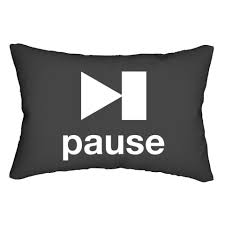

## Create a Chat LLM
---
Now let's try creating a slightly-more sophisticated model, a Chat LLM.

What makes a chat model different from another LLM? A Chat LLM can engage in dialogue, going back & forth with the user, unlike a text-completion LLM which responds (once) to a (single) prompt. Therefore, we'll have to create a slightly more complex set of prompts to interact with the model, including System Messages and User (or Human) Messages.

### Prompt Anatomy

We usually think of a "prompt" as a simple piece of text that we send to a model, as we have been doing thus far. But prompts can include more than that. For example, they might include **system instructions** (like, "Act as an expert in Python programming") or different **parameters** like temperature to control randomness.

There are three types of messages with an LLM:

* **system messages** describe the behavior of the AI assistant. A useful system message for data science use cases is "You are a helpful assistant who understands data science."
* **user messages** describe what you want the AI assistant to say. We'll cover examples of user messages throughout this tutorial
* **assistant messages** describe previous responses in the conversation. We'll cover how to have an interactive conversation later in this lab.

The first message should be a system message. Additional messages should alternate between the user and the assistant.

Let's create a chat LLM, then be a little more specific about our prompts to it.

In [9]:
# Feel free to select a new LLM from our list.
llm_model = "openrouter/openai/gpt-4.1-nano" #@param ['openrouter/openai/gpt-4.1-nano', 'openrouter/openai/gpt-4.1-mini', 'openrouter/openai/gpt-5-nano', 'openrouter/openai/gpt-5-mini', 'openrouter/google/gemini-2.5-flash']

# Define the system message
SYSTEM_MESSAGE = 'You are a helpful assistant who understands the business of interior decorating.'

# Define the user message
USER_MESSAGE = 'What color paint should I use for a living room in a house in the mountains near Denver?'

messages_chat = [
    {"content": SYSTEM_MESSAGE, "role": "system"},
    {"content": USER_MESSAGE, "role": "user"}
]

### Note: We can add streaming in order to help with seeing the initial outputs sooner.
response = completion(model=llm_model, messages=messages_chat, temperature=1, stream=True)
res_so_far = ""
for part in response:
  if part.choices[0].delta.content:
    res_so_far += part.choices[0].delta.content
  print(res_so_far)
  clear_output(wait=True)

For a mountain house near Denver, you'll want colors that complement the natural surroundings and create a warm, inviting atmosphere. Consider earthy, neutral tones or muted shades inspired by the outdoors. Here are some suggestions:

1. **Warm Taupe or Greige (Gray + Beige):** These versatile neutral tones work well with mountain scenery and can complement wooden accents and rustic decor.

2. **Soft Sage Green:** Echoes the lush greenery and adds a calming vibe to the space.

3. **Deep, Rich Browns or Chocolate:** Perfect for creating cozy, inviting spaces that reflect the natural wood and stone elements often found in mountain homes.

4. **Muted Blue or Slate:** Brings a cool, serene feeling that’s reminiscent of mountain skies and lakes.

5. **Warm Ivory or Cream:** Light and airy, helping to brighten the space while maintaining a rustic charm.

6. **Accents in Forest Green, Burgundy, or Burnt Orange:** These can add pops of color inspired by the forest, sunset, and fall foliage wit

In [10]:
display(Markdown(res_so_far))

For a mountain house near Denver, you'll want colors that complement the natural surroundings and create a warm, inviting atmosphere. Consider earthy, neutral tones or muted shades inspired by the outdoors. Here are some suggestions:

1. **Warm Taupe or Greige (Gray + Beige):** These versatile neutral tones work well with mountain scenery and can complement wooden accents and rustic decor.

2. **Soft Sage Green:** Echoes the lush greenery and adds a calming vibe to the space.

3. **Deep, Rich Browns or Chocolate:** Perfect for creating cozy, inviting spaces that reflect the natural wood and stone elements often found in mountain homes.

4. **Muted Blue or Slate:** Brings a cool, serene feeling that’s reminiscent of mountain skies and lakes.

5. **Warm Ivory or Cream:** Light and airy, helping to brighten the space while maintaining a rustic charm.

6. **Accents in Forest Green, Burgundy, or Burnt Orange:** These can add pops of color inspired by the forest, sunset, and fall foliage without overwhelming the space.

**Additional Tips:**
- Consider the amount of natural light; mountain homes often have large windows, so test paint samples in different lighting conditions.
- If your decor features wood or stone, choose colors that harmonize with those materials.
- For a cozy atmosphere, darker or richer hues can create warm, intimate spaces, while lighter tones keep the room feeling spacious and bright.

Would you like suggestions tailored for a specific room or decor style?

### Task 2

Try setting a different `SYSTEM_MESSAGE` variable in the below cell and see how it impacts the response.

Try:

*   Changing the role of the system;
*   Setting a "stylized" response for the system (e.g.: 'in the style of Gandalf from The Hobbit');
*   Etc.


In [11]:
# Define the system message
SYSTEM_MESSAGE = "You are a paint expert" #@param {"type": "string"}

# Define the user message
USER_MESSAGE = 'What color paint should I use for a living room in a house in the mountains near Denver?'

messages_chat = [
    {"content": SYSTEM_MESSAGE, "role": "system"},
    {"content": USER_MESSAGE, "role": "user"}
]

### Note: We can add streaming in order to help with seeing the initial outputs sooner.
response = completion(model=llm_model, messages=messages_chat, temperature=1)
display(Markdown(response.choices[0].message.content))

For a living room in a mountain house near Denver, you'll want colors that complement the natural surroundings, create warmth, and enhance the cozy mountain vibe. Here are some color suggestions:

1. **Earthy Tones**: Think warm browns, taupes, and beiges inspired by the mountain landscape and forest surroundings.
   - Example: Warm taupe or sandstone.

2. **Nature-Inspired Greens**: Soft, muted greens mimic the surrounding forests and add a calming element.
   - Example: Sage green or olive.

3. **Warm Grays**: Versatile and sophisticated, warm gray shades reflect the rocky mountain terrain.
   - Example: Greige (gray-beige).

4. **Deep Blues**: Inspired by mountain skies, navy or slate blue can add depth without feeling cold.
   - Example: Slate or navy.

5. **Accents and Trim**: Consider using darker tones like rich browns or charcoals for trims, or complementary accent walls.

**Additional tips:**
- Use semi-gloss or satin finishes for durability, especially if your living room has a lot of natural light or fireplace.
- Consider putting a sample on your wall to see how it looks in the lighting at different times of day.
- To enhance the mountain cozy feel, incorporate natural materials like wood or stone accents along with your paint choice.

Would you like specific color brand recommendations or shades?

**PAUSE** here. Did you do the task above? What did you learn?

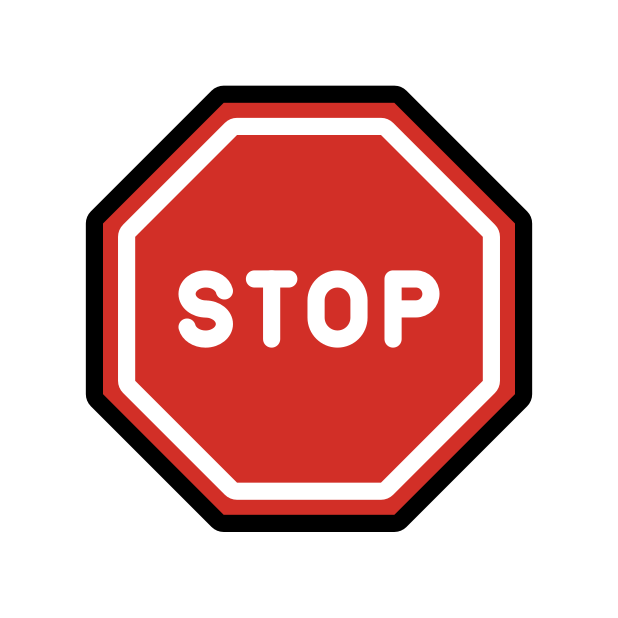

**STOP** here - end of Lab 1-A.

## LAB 1-B Complex Prompting

### Prompt Templates

Our prompts are starting to get a little complicated, with different types of messages and enforced order.

Let's explore the use of a "**prompt template**" to help with all of this, giving us a structured starting point for our prompts to pass to the chat *LLM*.

In [13]:
from typing import List, Dict
import pydantic

class SimplePromptTemplate(pydantic.BaseModel):
    city: str

    def format_string(self) -> str:
        return f"What color paint should I use for a house in {self.city}?"


In [14]:
# Provide the value for the placeholder to create the prompt
City = "La Crosse" #@param {"type": "string"}
filled_prompt = SimplePromptTemplate(city=City.strip()).format_string()
print(filled_prompt)

What color paint should I use for a house in La Crosse?


In [15]:
# Define the system message
SYSTEM_MESSAGE = 'You are a helpful assistant who understands the business of interior decorating specifically in Wisconsin.'

messages_chat = [
    {"content": SYSTEM_MESSAGE, "role": "system"},
    {"content": filled_prompt, "role": "user"}
]

### Note: We can add streaming in order to help with seeing the initial outputs sooner.
response = completion(model=llm_model, messages=messages_chat, temperature=1)
display(Markdown(response.choices[0].message.content))

Choosing the right paint color for your house in La Crosse, Wisconsin, depends on several factors including your personal style, the architectural style of your home, and the surrounding environment. However, considering La Crosse's natural scenery and climate, here are some suggestions that work well:

1. **Earth Tones and Neutrals:**  
   - Warm taupes, beiges, and greiges (gray-beige) blend beautifully with the natural landscape of the Mississippi River, bluffs, and forests.  
   - These colors create a timeless, welcoming look and are versatile for both exterior and interior spaces.

2. **Muted Greens and Blues:**  
   - Soft sage green or muted blue shades complement the lush greenery and water views around La Crosse.  
   - They evoke a calming, nature-inspired feel.

3. **Classic Whites and Creams:**  
   - Crisp white or creamy tones can give your house a fresh, clean look that also highlights architectural details.

4. **Accent Colors:**  
   - Consider using bolder but harmonious accent colors like deep navy, forest green, or brick red for doors, shutters, or trim to add character.

**Additional Tips:**  
- Check with local paint suppliers or decorators for color samples, especially for the exterior, since the local climate can affect how paint colors appear over time.  
- Consider the surrounding landscape and neighboring homes to ensure your color scheme complements the neighborhood.  
- Test color samples on your home’s exterior or interior walls before making final decisions.

Would you like specific palette recommendations or help with selecting paint for interior vs. exterior?

### Token Mechanics

Our goals in this section are to understand what tokens are, how they are used in LLMs, and how to estimate both input and output costs of token use. Tokens can be thought of as pieces of words. Before the LLM API processes a request, the input is broken down into *tokens*. These tokens are not necessarily defined by exactly where the words start or end - tokens can include trailing spaces and even sub-words.

* For hands-on exploration of tokenization, you can use OpenAI's [interactive Tokenizer tool](https://platform.openai.com/tokenizer), which allows you to calculate the number of tokens and see how text is broken into tokens.

* You can find details on OpenAI's token pricing [here](https://openai.com/pricing).

Let's first look at an extremely simple example of tracking token usage for a single LLM call.

In [16]:
USER_INPUT = 'Can you tell me the name of the best movie of all time?'
response = completion(model=llm_model,temperature=0.8,
                      messages=[{'role': 'user', 'content': USER_INPUT}])

display(Markdown(response.choices[0].message.content))

print(f"Usage Information:\n{response.json()['usage']}")

Determining the "best" movie of all time is subjective and can vary depending on personal taste, cultural influences, and criteria such as storytelling, innovation, or critical acclaim. However, some films frequently cited as among the greatest include *Citizen Kane* (1941), *The Godfather* (1972), *Casablanca* (1942), and *Schindler's List* (1993). If you have a specific genre or style in mind, I can help recommend movies that might suit your preferences!

Usage Information:
{'completion_tokens': 106, 'prompt_tokens': 21, 'total_tokens': 127, 'completion_tokens_details': {'audio_tokens': 0, 'reasoning_tokens': 0, 'image_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': 0, 'cached_tokens': 0, 'video_tokens': 0, 'cache_creation_tokens': 0}, 'cost': 4.45e-05, 'is_byok': False, 'cost_details': {'upstream_inference_cost': 4.45e-05, 'upstream_inference_prompt_cost': 2.1e-06, 'upstream_inference_completions_cost': 4.24e-05}}


### Task 3

Notice that if you rerun the above cell multiple times, you will get different prompt outputs and costs (total tokens) associated with it!

Try running that code a few more times.
* Does the output change?
* Does the output change if you change the prompt?
* Does the output change if you make the prompt more complex?

In [17]:
### For this example, we will set the llm_model to gemini-2.5-flash
llm_model = "openrouter/google/gemini-2.5-flash"
USER_INPUT = 'Can you tell me the name of the best movie of all time?'

response = completion(model=llm_model,temperature=0.3,
                      messages=[{'role': 'user', 'content': USER_INPUT}])

display(Markdown(response.choices[0].message.content))

print(f"Usage Information:\n{response.json()['usage']}")

That's a fun question, but also a tricky one! There's no single "best movie of all time" because what makes a movie great is incredibly subjective and depends on individual taste, cultural background, and even what someone is looking for in a film at a particular moment.

However, I can tell you about some movies that are consistently cited in "best of all time" lists, are highly influential, and have stood the test of time:

**Frequently Cited as the "Greatest":**

*   **Citizen Kane (1941):** Often tops critics' lists. Praised for its innovative narrative structure, cinematography, and Orson Welles' groundbreaking direction. It revolutionized filmmaking techniques.
*   **The Godfather (1972):** A powerful crime epic that is beloved by audiences and critics alike. Known for its masterful storytelling, iconic performances (Marlon Brando, Al Pacino), and exploration of family, power, and morality.
*   **Casablanca (1942):** A timeless romantic drama with unforgettable characters, witty dialogue, and a powerful emotional core. It's a classic for a reason.
*   **2001: A Space Odyssey (1968):** A visually stunning and intellectually challenging science fiction masterpiece by Stanley Kubrick. It pushed the boundaries of filmmaking and explored profound themes.
*   **Seven Samurai (1954):** Akira Kurosawa's epic Japanese jidaigeki film that has influenced countless action and adventure movies. It's a masterclass in character development and storytelling.

**Other Highly Acclaimed and Beloved Films:**

*   **Schindler's List (1993):** A profoundly moving and important historical drama.
*   **Pulp Fiction (1994):** A highly influential and stylish crime film that redefined independent cinema.
*   **The Shawshank Redemption (1994):** A perennial audience favorite, known for its themes of hope and perseverance.
*   **Vertigo (1958):** Alfred Hitchcock's psychological thriller, often cited for its innovative camera work and complex themes.
*   **Tokyo Story (1953):** A quiet, deeply moving Japanese drama about family and aging.

**To help me narrow it down for *you*, you could tell me:**

*   What genres do you usually enjoy? (e.g., sci-fi, drama, comedy, horror)
*   Are you looking for something thought-provoking, entertaining, visually stunning, or emotionally impactful?
*   Do you prefer older classics or more modern films?

Ultimately, the "best movie of all time" is the one that resonates most deeply with *you*.

Usage Information:
{'completion_tokens': 573, 'prompt_tokens': 14, 'total_tokens': 587, 'completion_tokens_details': {'audio_tokens': 0, 'reasoning_tokens': 0, 'image_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': 0, 'cached_tokens': 0, 'video_tokens': 0, 'cache_creation_tokens': 0}, 'cost': 0.0014367, 'is_byok': False, 'cost_details': {'upstream_inference_cost': 0.0014367, 'upstream_inference_prompt_cost': 4.2e-06, 'upstream_inference_completions_cost': 0.0014325}}


**PAUSE** here. Did you do the task above? What did you learn?

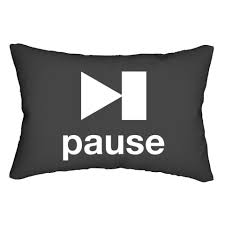

### Model Experimentation

For the second part of our lab, we will perform:

- **Model Comparison**: Evaluate different LLMs
- **Parameter Experimentation**: Experiment with temperature, top_p and other parameter settings
- **Advanced Techniques**: Practice zero-shot, few-shot, and Chain-of-Thought prompting

**Model Comparison**

Let's start by comparing OpenAI's `gpt-4.1-nano` with Gemini's `gemini-2.5-flash`.

Check to see if the responses differ at all from the previous responses you received.

In [18]:
# The models worth trying are the verified ones, not everything in the catalogue:
# every id below answered a live call when this lab was prepared.
for _model in VERIFIED_MODELS:
    print(_model)

openrouter/openai/gpt-4.1-nano
openrouter/openai/gpt-4.1-mini
openrouter/openai/gpt-5-nano
openrouter/openai/gpt-5-mini
openrouter/google/gemini-2.5-flash
openrouter/google/gemini-2.5-flash-lite


In [19]:
prompt_to_test = "how to test the effectiveness of an llm?"



gpt_4_1_nano_response = completion(model='openrouter/openai/gpt-4.1-nano',temperature=0.8,
                      messages=[{'role': 'user', 'content': prompt_to_test}])

gemini_2_5_flash_response = completion(model='openrouter/google/gemini-2.5-flash',temperature=0.8,
                      messages=[{'role': 'user', 'content': prompt_to_test}])

print("gpt-4.1-nano response:")
display(Markdown(gpt_4_1_nano_response.choices[0].message.content))
print("Gemini-2.5-flash response:")
display(Markdown(gemini_2_5_flash_response.choices[0].message.content))


gpt-4.1-nano response:


Testing the effectiveness of a Large Language Model (LLM) involves evaluating its performance across various criteria to ensure it meets the desired standards for accuracy, reliability, and usefulness. Here are some common approaches and metrics used to assess an LLM's effectiveness:

### 1. **Benchmarking with Standard Datasets**
- **Purpose:** To compare the model's performance against established standards.
- **Examples:** 
  - **GLUE, SuperGLUE** for natural language understanding.
  - **SQuAD** for question answering.
  - **BLEU, ROUGE** for summarization.
- **Method:** Run the model on these datasets and measure metrics like accuracy, F1 score, BLEU, ROUGE, etc.

### 2. **Task-Specific Evaluation**
- **Purpose:** To assess performance on specific applications such as translation, summarization, chatbots, etc.
- **Method:** Use domain-relevant datasets and metrics to evaluate how well the model performs in real-world scenarios.

### 3. **Human Evaluation**
- **Purpose:** To assess qualitative aspects like coherence, relevance, factual correctness, and user satisfaction.
- **Method:** Human annotators rate the outputs based on predefined criteria or through user studies.

### 4. **Automated Metrics**
- **Common Metrics:**
  - **Perplexity:** Measures how well the model predicts a sample (lower is better).
  - **Accuracy, Precision, Recall, F1:** For classification tasks.
  - **BLEU, ROUGE, METEOR:** For translation and summarization quality.
  - **Exact Match:** For question answering.

### 5. **Robustness and Generalization Testing**
- Evaluate how well the model handles:
  - **Adversarial examples**
  - **Noisy inputs**
  - **Out-of-distribution data**

### 6. **Bias and Fairness Assessment**
- Analyze outputs for unintended biases or unfair representations across different demographic groups.

### 7. **Efficiency and Scalability**
- Measure inference speed, memory usage, and adaptability to different hardware.

### 8. **Longitudinal and Real-World Testing**
- Deploy the model in real-world environments to monitor ongoing performance, user feedback, and error rates over time.

---

**In summary:**  
Effectiveness testing of an LLM is multidimensional, combining quantitative metrics, qualitative assessments, robustness checks, and real-world evaluations to comprehensively understand its capabilities and limitations.

Gemini-2.5-flash response:


Testing the effectiveness of an LLM is a multifaceted and challenging process, as "effectiveness" can mean different things depending on the intended use case. Here's a comprehensive guide to how you can test an LLM, broken down into various aspects:

## I. Defining "Effectiveness" for Your Use Case

Before you even start testing, clearly define what "effective" means for your specific application. This will guide your choice of metrics and testing methods.

**Consider these aspects:**

*   **Accuracy/Correctness:** Does it provide factually correct information?
*   **Relevance:** Is the output pertinent to the prompt?
*   **Coherence/Fluency:** Is the language natural, easy to understand, and logically structured?
*   **Completeness:** Does it address all parts of the prompt?
*   **Conciseness:** Is the output free of unnecessary verbosity?
*   **Safety/Harmfulness:** Does it avoid generating toxic, biased, or dangerous content?
*   **Robustness:** Does it perform consistently across different inputs (e.g., slight rephrasing)?
*   **Latency/Throughput:** How fast does it generate responses? (Important for real-time applications)
*   **Cost:** What are the computational resources required?
*   **Creativity/Novelty:** For creative tasks, how original and engaging is the output?
*   **Adherence to Instructions:** Does it follow specific formatting, tone, or length requirements?
*   **Bias:** Does it perpetuate or amplify societal biases?

## II. Testing Methodologies

There are several approaches to testing LLMs, often used in combination.

### A. Quantitative/Automated Evaluation

These methods use metrics and datasets to objectively measure performance.

1.  **Benchmark Datasets:**
    *   **Description:** Use established, publicly available datasets designed to test specific capabilities (e.g., QA, summarization, reasoning).
    *   **Examples:**
        *   **GLUE/SuperGLUE:** General language understanding.
        *   **SQuAD:** Question Answering.
        *   **CNN/DailyMail:** Summarization.
        *   **GSM8K:** Math word problems.
        *   **MMLU:** Multitask Language Understanding (wide range of subjects).
        *   **HELM:** Holistic Evaluation of Language Models (comprehensive benchmark framework).
    *   **Pros:** Standardized, reproducible, allows comparison with other models, efficient for large-scale testing.
    *   **Cons:** Can be limited in scope, may not reflect real-world use cases, models can "overfit" to benchmarks.

2.  **Task-Specific Metrics:**
    *   **Description:** Apply metrics relevant to your specific task.
    *   **Examples:**
        *   **Summarization:** ROUGE, BLEU (for comparing generated text to reference summaries).
        *   **Translation:** BLEU, METEOR.
        *   **Classification:** Accuracy, Precision, Recall, F1-score.
        *   **Question Answering:** Exact Match (EM), F1-score (overlap with reference answers).
        *   **Code Generation:** Pass@k (percentage of generated code that passes unit tests).
    *   **Pros:** Direct measurement of performance on specific tasks.
    *   **Cons:** Requires ground truth data, metrics can sometimes be imperfect proxies for human judgment.

3.  **Adversarial Testing:**
    *   **Description:** Deliberately craft prompts to challenge the model's limitations, identify vulnerabilities, and provoke undesirable behavior.
    *   **Examples:**
        *   **Jailbreaking:** Trying to bypass safety filters.
        *   **Prompt Injection:** Manipulating the model's instructions.
        *   **Typographical Errors:** Testing robustness to noise.
        *   **Ambiguous Queries:** Seeing how it handles uncertainty.
        *   **Contradictory Information:** Testing its ability to identify inconsistencies.
    *   **Pros:** Uncovers edge cases and failure modes, crucial for safety and robustness.
    *   **Cons:** Can be time-consuming, requires creativity.

4.  **Bias & Fairness Evaluation:**
    *   **Description:** Use specialized datasets and metrics to detect and quantify biases (e.g., gender, racial, socioeconomic).
    *   **Examples:**
        *   **WEAT (Word Embedding Association Test):** Measures implicit biases in word embeddings.
        *   **StereoSet:** Measures stereotypical associations in language models.
        *   **Contextualized Bias Detection:** Analyzing model outputs for biased language in specific contexts.
    *   **Pros:** Essential for ethical AI development.
    *   **Cons:** Defining and measuring bias is complex and often subjective.

### B. Qualitative/Human Evaluation

These methods rely on human judgment to assess the quality of the LLM's output.

1.  **Expert Human Review:**
    *   **Description:** Domain experts or trained annotators evaluate model outputs based on a predefined rubric.
    *   **Process:**
        *   Define clear criteria (e.g., accuracy, relevance, fluency, tone, safety).
        *   Provide examples of good and bad outputs.
        *   Have multiple annotators to ensure inter-rater reliability.
        *   Use rating scales or binary judgments.
    *   **Pros:** Gold standard for many aspects of quality, captures nuances automated metrics miss, identifies subtle errors.
    *   **Cons:** Expensive, time-consuming, subjective (requires careful rubric design and training), not scalable for large volumes.

2.  **A/B Testing (User Studies):**
    *   **Description:** Deploy the LLM in a controlled environment (e.g., A/B test in a product) and gather user feedback or observe user behavior.
    *   **Metrics:** Click-through rates, task completion rates, user satisfaction scores, time spent, explicit feedback.
    *   **Pros:** Real-world validation, directly measures impact on user experience, identifies practical issues.
    *   **Cons:** Requires a live product environment, ethical considerations, takes time to gather sufficient data.

3.  **Wizard of Oz Testing:**
    *   **Description:** A human "wizard" secretly controls or augments the LLM's responses, making users believe they are interacting solely with the AI. This helps to understand user expectations and pain points before full automation.
    *   **Pros:** Gathers insights into user expectations and interaction patterns, helps refine the desired AI behavior.
    *   **Cons:** Resource-intensive, ethical considerations regarding deception.

4.  **Red Teaming:**
    *   **Description:** A specialized form of adversarial testing where a team actively tries to make the LLM generate harmful, biased, or incorrect content.
    *   **Pros:** Crucial for identifying and mitigating safety risks, helps develop robust safety mechanisms.
    *   **Cons:** Can be resource-intensive, requires skilled red teamers.

## III. Practical Steps for Testing

1.  **Define Your Goal & Use Case:** What problem is the LLM solving? Who are the users?
2.  **Select Key Metrics:** Based on your goal, choose the most relevant quantitative and qualitative metrics.
3.  **Curate/Generate Test Data:**
    *   **Representative Data:** Use data that closely mirrors real-world inputs.
    *   **Edge Cases:** Include unusual, ambiguous, or difficult queries.
    *   **Negative Examples:** Prompts designed to provoke errors or undesirable outputs.
    *   **Ground Truth:** For quantitative metrics, you'll need human-annotated "correct" answers.
4.  **Establish Baselines:** Compare your LLM's performance against:
    *   Previous versions of the model.
    *   Other LLMs (open-source or commercial).
    *   Human performance (if applicable).
    *   Simpler rule-based systems (to ensure the LLM isn't over-engineered).
5.  **Iterative Testing:** LLM development and testing is an iterative process.
    *   Test, analyze results, identify weaknesses.
    *   Fine-tune, re-prompt, or adjust the model/application.
    *   Repeat.
6.  **Tooling:**
    *   **Prompt Engineering Tools:** For managing and versioning prompts.
    *   **Evaluation Frameworks:** Libraries like `evaluate` (Hugging Face), `ragas` (for RAG applications), or custom scripts.
    *   **Annotation Platforms:** For human labeling (e.g., Label Studio, Prodigy).
    *   **Observability Tools:** For monitoring model performance in production (latency, error rates, token usage).
7.  **Documentation:** Keep detailed records of your tests, results, and insights. This is crucial for reproducibility and tracking progress.

## IV. Specific Considerations for Different LLM Applications

*   **Chatbots/Conversational AI:** Focus on coherence, relevance, turn-taking, persona consistency, error handling, and ability to stay on topic.
*   **Summarization:** ROUGE scores, human readability, informativeness, factual consistency, absence of hallucinations.
*   **Code Generation:** Pass@k, syntax correctness, efficiency, security vulnerabilities.
*   **Content Generation (Creative):** Novelty, engagement, adherence to style/tone, absence of boilerplate.
*   **Retrieval-Augmented Generation (RAG):** RAG-specific metrics like "Faithfulness," "Answer Relevance," "Context Relevance," and "Context Recall."
*   **Translation:** BLEU, METEOR, human fluency, accuracy of meaning.

By combining these quantitative and qualitative methods, and by clearly defining what "effectiveness" means for your specific use case, you can develop a robust and comprehensive testing strategy for your LLM.

**PAUSE**, and consider the above. Play with it! Try other questions!

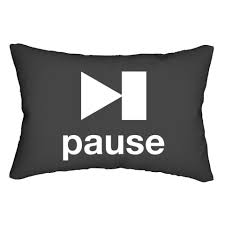

### Parameter Experimentation

Try simple things like changing the temperature of the model.

In [20]:
# gpt-4.1-nano on purpose. The gpt-5 models ignore `temperature` entirely, and
# litellm.drop_params = True hides that by silently dropping the argument.
for temperature in [0, 0.5, 1]:
  print(f"Temperature = {temperature}:")
  response = completion(model='openrouter/openai/gpt-4.1-nano',temperature=temperature,
                      messages=[{'role': 'user', 'content': "Why is the sky blue? Answer in 30 words or less"}])
  display(Markdown(response.choices[0].message.content))

Temperature = 0:


The sky appears blue because sunlight scatters off Earth's atmosphere; blue light scatters more than other colors due to its shorter wavelength, making the sky look blue to our eyes.

Temperature = 0.5:


The sky appears blue because sunlight scatters off Earth's atmosphere; blue light scatters more than other colors due to its shorter wavelength.

Temperature = 1:


The sky appears blue because sunlight scatters off molecules in Earth's atmosphere, with blue light scattering more than other colors due to its shorter wavelength.

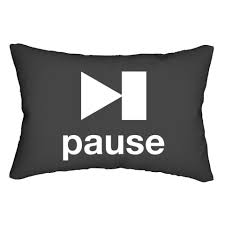

**PAUSE** here. What did you notice about the different temperature settings?

### Advanced Techniques

Practice zero-shot, few-shot, and Chain-of-Thought prompting.

**Zero-Shot Prompting**

Zero-shot prompting occurs when a model is asked to perform a task without any prior examples or context about how to perform that specific task. The prompt must be self-contained, as the model relies solely on its pre-trained knowledge to generate a response.

Example Prompt:
* Summarize the key impacts of the 2020 global pandemic on remote work trends.

In this case, the model is expected to understand what is being asked and use its internal knowledge to provide a summary without any additional examples or guidance.


In [21]:
# try zero-shot
prompt = "Summarize the top 3 key impacts of the 2020 global pandemic on remote work trends."
res_zero = completion(model='openrouter/google/gemini-2.5-flash',temperature=1,
                      messages=[{'role': 'user', 'content': prompt}])

display(Markdown(res_zero.choices[0].message.content))

The 2020 global pandemic irrevocably reshaped remote work, leading to three key impacts:

1.  **Massive and Rapid Forced Adoption:** Prior to the pandemic, remote work was a niche benefit for many companies. The pandemic, however, forced an unprecedented, widespread, and rapid shift to remote work for millions of employees globally. This demonstrated that remote work was not only possible for many roles but also efficient and, in some cases, even more productive. It shattered pre-existing assumptions and resistance from many employers who previously believed it couldn't work for their businesses.

2.  **Permanent Hybrid and Remote Work Models Emerge as the New Standard:** The forced experiment of 2020 proved the viability of remote work for many organizations. As a result, even after the acute phase of the pandemic subsided, a significant portion of companies did not return to full-time in-office setups. Instead, they adopted permanent hybrid models (combining in-office and remote days) or fully remote policies. This shift fundamentally altered expectations for employees and talent acquisition, making flexible work arrangements a crucial factor in hiring and retention.

3.  **Acceleration of Digital Transformation and Cloud-Based Technologies:** To support the sudden and widespread move to remote work, businesses had to rapidly invest in and implement digital tools and cloud-based infrastructure. This included widespread adoption of video conferencing platforms, collaboration software, secure remote access solutions, and cloud computing services. The pandemic acted as a powerful catalyst for digital transformation, accelerating timelines for technology adoption and establishing a more digitally reliant and geographically dispersed workforce.


**Few-Shot Prompting**

Few-shot prompting involves providing a few examples to the model before presenting the actual task. This approach helps the model understand the desired format or the specific type of response needed.

Example Prompt:

```
Example 1: Translate the English phrase "Hello, how are you?" to Spanish.
Answer: Hola, como estás?

Example 2: Translate the English phrase "What time is it?" to Spanish.
Answer: Qué hora es?

Prompt: Translate the English phrase "Where is the nearest restaurant?" to Spanish.
```

Here, the model is shown two examples of translation tasks, which sets the expectation that it should translate the third phrase from English to Spanish in a similar format.

In [22]:
# try few-shot prompting
prompt = """
  Below are a few examples, followed by the prompt for you to follow.

  Example 1: Translate the English phrase "Hello, how are you?" to Spanish.
  Answer: Hola, como estás?

  Example 2: Translate the English phrase "What time is it?" to Spanish.
  Answer: Qué hora es?

  Prompt: Translate the English phrase "Where is the nearest restaurant?" to Spanish."""

res_few = completion(model='openrouter/google/gemini-2.5-flash',temperature=1,
                    messages=[{'role': 'user', 'content': prompt}])

display(Markdown(res_few.choices[0].message.content))

Answer: ¿Dónde está el restaurante más cercano?

**Chain-of-Thought Prompting**

Chain-of-Thought prompting guides the model through a logical sequence of steps or thoughts to reach a conclusion, particularly useful for complex reasoning tasks. This method helps models handle problems that require multiple inferential steps.

Example Prompt:

```
Question: A farmer has 17 sheep, and all but 9 die. How many are left alive?
Chain of Thought: The phrase "all but 9 die" means that 9 sheep remain alive.
Answer: 9
```

In this example, the prompt explicitly outlines the reasoning process needed to answer the question, leading the model to the correct interpretation and response.

In [23]:
# try chain-of-thought prompting
prompt = """
  I will pose a question, and you will provide your chain-of-thought reasoning to reach the answer.

  Question: A farmer has 17 sheep, and all but 9 die. How many are left alive?"""

res_cot = completion(model='openrouter/openai/gpt-4.1-nano',temperature=1,
                    messages=[{'role': 'user', 'content': prompt}])

display(Markdown(res_cot.choices[0].message.content))


Let's analyze the question carefully:

The farmer initially has 17 sheep. The phrase "all but 9 die" means that all of the sheep except for 9 die. So, the only sheep still alive are the 9 that did not die.

Therefore, the number of sheep left alive is **9**.

**Answer: 9**

**Usage Tips:**

* **Zero-Shot**: Useful when querying general knowledge or opinions, or when the task is straightforward.
* **Few-Shot**: Effective for tasks that require specific formats or where a model needs examples to "learn" the task quickly.
* **Chain-of-Thought**: Best for complex reasoning, mathematics, or multi-step logical problems.

## 3. AI Safety Challenge

For the third and final part of this lab, we will do a:

- **Prompt Hacking Exercise**: Test the limits of AI safety with Lakera's prompt-injection games*
  - URL: https://play.lakera.ai/agent-breaker
  - Objective: Attempt to "hack" the AI apps using creative prompting techniques
  - Time: Utilize any remaining lab time to see how far you can get. No key and no sign-up needed.
  - Note: this is where Lakera's older Gandalf challenge now redirects to.

*Note: For further exploration, look into safety tools like Meta's Prompt Guard and LLaMA Guard.


### Turning the custom widget manager back off

The first cell of this notebook switched on Colab's custom widget manager, which is what
lets the model table and the dropdown render. It stays on for the rest of the session,
and it is needed all the way through Lab 1-B, which is why this cell lives at the end
rather than in the middle. Run it only if you want the support off again.


In [26]:
from google.colab import output
output.disable_custom_widget_manager()